In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CHURN_DAYS = 1
CSV_PATH = "data.csv"


In [41]:
df = pd.read_csv(CSV_PATH)
len(df[df.status == 'Complete']['user_id'].unique())

27473

In [91]:
import pandas as pd
import numpy as np

CHURN_DAYS = 1
CSV_PATH = "data.csv"

# ---------- robust datetime parser ----------
def parse_mixed_datetime(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.replace({
        "": np.nan, " ": np.nan, "null": np.nan, "none": np.nan,
        "nan": np.nan, "nat": np.nan, "na": np.nan, "n/a": np.nan
    })

    # pass 1: обычный парсинг строк
    dt = pd.to_datetime(s, utc=True, errors="coerce")

    # pass 2: если есть числа (epoch), пытаемся подобрать unit
    bad = dt.isna() & s.notna()
    if bad.any():
        num = pd.to_numeric(s[bad], errors="coerce")
        num = num.dropna()
        if len(num) > 0:
            best_dt = None
            best_score = -1
            for unit in ["s", "ms", "us", "ns"]:
                cand = pd.to_datetime(num, unit=unit, utc=True, errors="coerce")
                # реалистичный диапазон дат
                score = ((cand.dt.year >= 2000) & (cand.dt.year <= 2035)).sum()
                if score > best_score:
                    best_score = score
                    best_dt = cand
            if best_dt is not None:
                dt.loc[best_dt.index] = best_dt

    return dt


# ---------- 1) загрузка ----------
required_cols = [
    "order_id", "user_id", "created_at", "delivered_at",
    "delivery_latitude", "delivery_longitude", "warehouse_latitude", "warehouse_longitude"
]
df_all = pd.read_csv(CSV_PATH, dtype=str)

missing = [c for c in required_cols if c not in df_all.columns]
if missing:
    raise ValueError(f"В data.csv нет нужных колонок: {missing}")

# ---------- 2) парсим даты ----------
df_all["created_at_dt"] = parse_mixed_datetime(df_all["created_at"])
df_all["delivered_at_dt"] = parse_mixed_datetime(df_all["delivered_at"])

# если created_at плохо парсится, пробуем fallback на sold_at
start_col = "created_at_dt"
if "sold_at" in df_all.columns:
    sold_dt = parse_mixed_datetime(df_all["sold_at"])
    if sold_dt.notna().sum() > df_all["created_at_dt"].notna().sum():
        df_all["created_at_dt"] = sold_dt
        start_col = "created_at_dt"

# ---------- 3) фильтр по факту доставки ----------
df = df_all.dropna(subset=["user_id", "order_id", "delivered_at_dt", start_col]).copy()

# ---------- 4) время доставки ----------
df["delivery_days"] = (df["delivered_at_dt"] - df[start_col]).dt.total_seconds() / 86400
df = df[df["delivery_days"].notna()].copy()
df = df[(df["delivery_days"] >= 0) & (df["delivery_days"] <= 120)].copy()  # жесткий безопасный диапазон

# если хотим дополнительно убрать хвост — только когда upper не NaN
if len(df) > 100:
    upper = df["delivery_days"].quantile(0.995)
    if pd.notna(upper):
        df = df[df["delivery_days"] <= upper].copy()

if df.empty:
    raise ValueError("После всех корректировок дат не осталось валидных строк. Покажи head() created_at/delivered_at — добьем формат.")

# ---------- 5) уровень заказа ----------
order_df = (
    df.sort_values(["order_id", start_col])
      .drop_duplicates(subset=["order_id"], keep="first")
      .copy()
)

# ---------- 6) churn ----------
# конец наблюдения из всех покупок
obs_end = df_all["created_at_dt"].max()
if pd.isna(obs_end):
    obs_end = order_df[start_col].max()

last_purchase = order_df.groupby("user_id", as_index=False)[start_col].max()
last_purchase["days_since_last"] = (obs_end - last_purchase[start_col]).dt.days
last_purchase["churn"] = (last_purchase["days_since_last"] >= CHURN_DAYS).astype(int)

# ---------- 7) гео ----------
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

for c in ["delivery_latitude", "delivery_longitude", "warehouse_latitude", "warehouse_longitude"]:
    order_df[c] = pd.to_numeric(order_df[c], errors="coerce")

order_df["distance_km"] = haversine_km(
    order_df["warehouse_latitude"], order_df["warehouse_longitude"],
    order_df["delivery_latitude"], order_df["delivery_longitude"]
)

# ---------- 8) user-level ----------
user_features = order_df.groupby("user_id", as_index=False).agg(
    avg_delivery_days=("delivery_days", "mean"),
    median_delivery_days=("delivery_days", "median"),
    avg_distance_km=("distance_km", "mean"),
    orders=("order_id", "nunique"),
)

user_df = user_features.merge(
    last_purchase[["user_id", "days_since_last", "churn"]],
    on="user_id",
    how="inner"
).copy()

print("rows after delivery filter:", len(df))
print("users in order_df:", order_df["user_id"].nunique())
print("users in user_df:", len(user_df))
print("churn rate:", round(user_df["churn"].mean(), 4))
print(last_purchase["churn"].value_counts())


/var/folders/4q/x5dr881s2zq0c00_zny4zsfc0000gn/T/ipykernel_33857/2773465974.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = s.replace({


ValueError: После всех корректировок дат не осталось валидных строк. Покажи head() created_at/delivered_at — добьем формат.

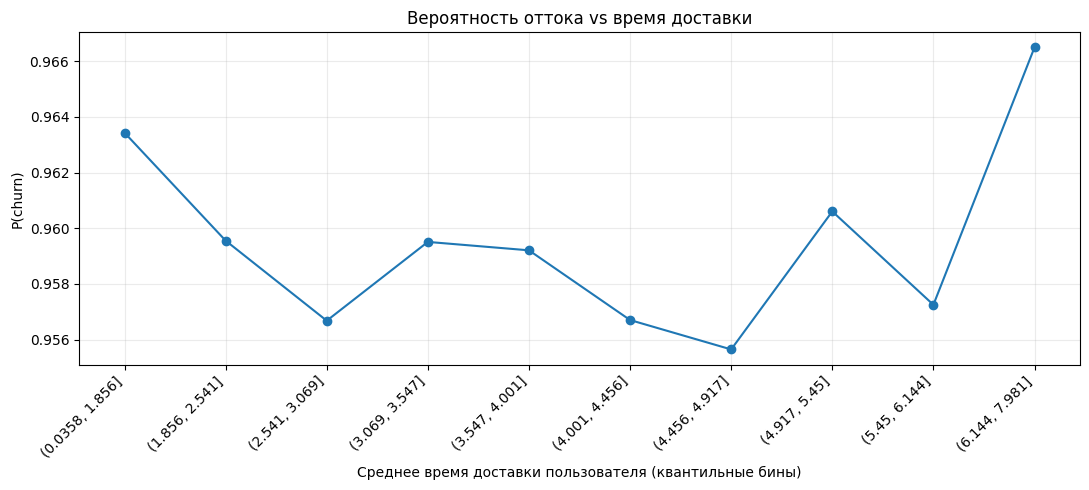

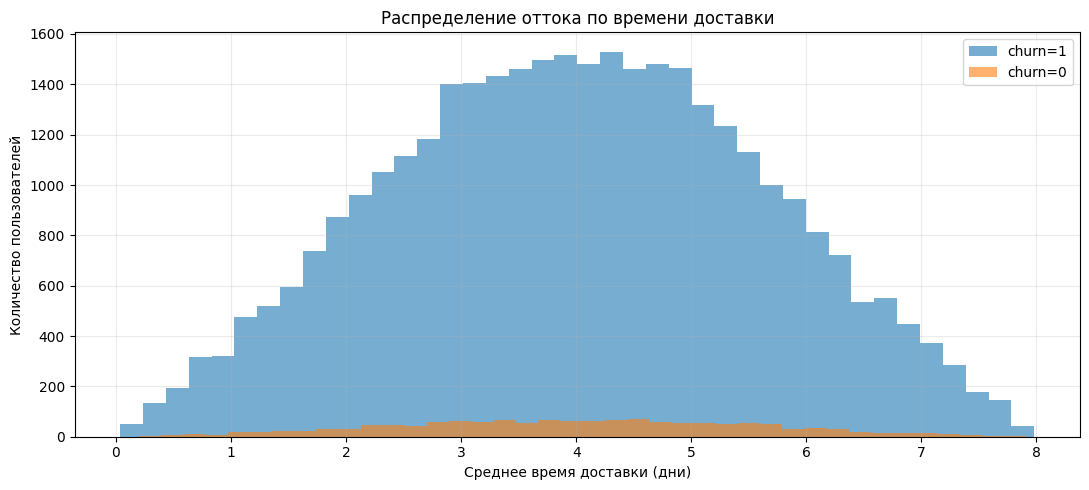

KeyError: ['avg_distance_km']

In [90]:
# График 1: P(churn) от времени доставки
q = min(10, int(user_df["avg_delivery_days"].nunique()))
user_df["delivery_bin"] = pd.qcut(user_df["avg_delivery_days"], q=q, duplicates="drop")
churn_by_bin = user_df.groupby("delivery_bin", observed=True, as_index=False)["churn"].mean()

plt.figure(figsize=(11, 5))
plt.plot(churn_by_bin["delivery_bin"].astype(str), churn_by_bin["churn"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Среднее время доставки пользователя (квантильные бины)")
plt.ylabel("P(churn)")
plt.title("Вероятность оттока vs время доставки")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# График 2: распределение churn по времени доставки
plt.figure(figsize=(11, 5))
plt.hist(user_df.loc[user_df["churn"] == 1, "avg_delivery_days"], bins=40, alpha=0.6, label="churn=1")
plt.hist(user_df.loc[user_df["churn"] == 0, "avg_delivery_days"], bins=40, alpha=0.6, label="churn=0")
plt.xlabel("Среднее время доставки (дни)")
plt.ylabel("Количество пользователей")
plt.title("Распределение оттока по времени доставки")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Дополнительно: география
geo_sample = user_df.dropna(subset=["avg_distance_km"]).copy()
if not geo_sample.empty and geo_sample["avg_distance_km"].nunique() > 1:
    plt.figure(figsize=(11, 5))
    plt.scatter(
        geo_sample["avg_distance_km"],
        geo_sample["avg_delivery_days"],
        c=geo_sample["churn"],
        alpha=0.2,
        s=10,
        cmap="coolwarm"
    )
    plt.colorbar(label="churn")
    plt.xlabel("Средняя дистанция доставки (км)")
    plt.ylabel("Среднее время доставки (дни)")
    plt.title("География: дистанция и время доставки")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# Выводы
corr_delivery_churn = user_df["avg_delivery_days"].corr(user_df["churn"], method="spearman")
mean_delivery_churn = user_df.loc[user_df["churn"] == 1, "avg_delivery_days"].mean()
mean_delivery_active = user_df.loc[user_df["churn"] == 0, "avg_delivery_days"].mean()

print("\n=== Метрики ===")
print(f"Пользователей в анализе: {len(user_df):,}")
print(f"Доля churn (N={CHURN_DAYS}): {user_df['churn'].mean():.3f}")
print(f"Средняя доставка (churn=1): {mean_delivery_churn:.2f} дн.")
print(f"Средняя доставка (churn=0): {mean_delivery_active:.2f} дн.")
print(f"Spearman(avg_delivery_days, churn): {corr_delivery_churn:.3f}")

if geo_sample.shape[0] > 0 and geo_sample["avg_distance_km"].nunique() > 1:
    corr_geo_delivery = geo_sample["avg_distance_km"].corr(geo_sample["avg_delivery_days"], method="spearman")
    corr_geo_churn = geo_sample["avg_distance_km"].corr(geo_sample["churn"], method="spearman")
    print(f"Spearman(distance_km, delivery_days): {corr_geo_delivery:.3f}")
    print(f"Spearman(distance_km, churn): {corr_geo_churn:.3f}")

print("\n=== Краткий вывод ===")
if pd.isna(corr_delivery_churn):
    print("Недостаточно вариативности, чтобы оценить связь churn и доставки")
elif corr_delivery_churn > 0:
    print("Есть положительная связь: чем дольше доставка, тем выше вероятность оттока")
elif corr_delivery_churn < 0:
    print("Есть отрицательная связь: при большей доставке отток не растет")
else:
    print("Связь почти нулевая")


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "data.csv"

# Загружаем нужные колонки
df = pd.read_csv(CSV_PATH, usecols=["user_id", "order_id", "created_at", "status"])

# Берем только завершенные покупки
df = df[df["status"] == "Complete"].copy()

# Дата
df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
df = df.dropna(subset=["user_id", "order_id", "created_at"])

# Важно: в одном заказе может быть несколько товаров -> оставляем 1 строку на order_id
orders = (
    df.sort_values(["user_id", "order_id", "created_at"])
      .drop_duplicates(subset=["order_id"], keep="first")
      .copy()
)

print(f"Уникальных пользователей: {orders['user_id'].nunique():,}")
print(f"Уникальных заказов: {orders['order_id'].nunique():,}")


Уникальных пользователей: 681
Уникальных заказов: 785


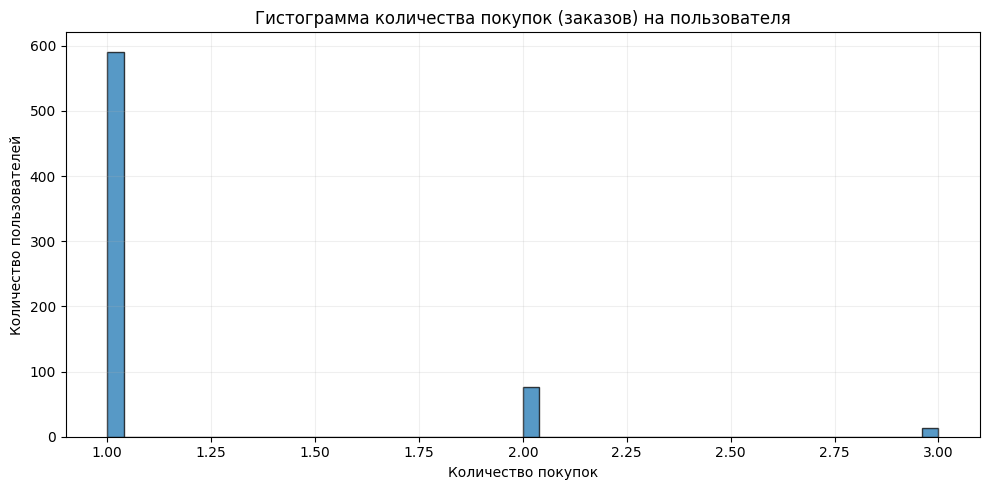

Пользователей с одной покупкой: 591


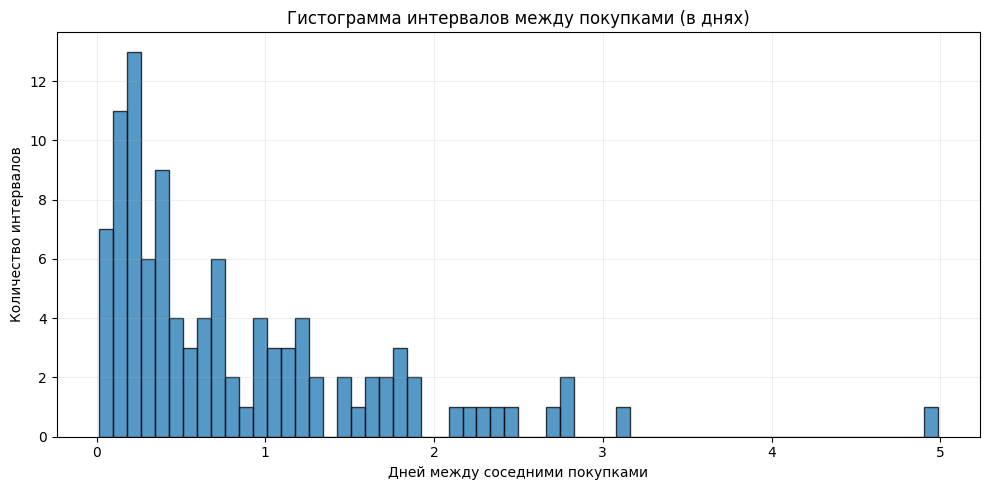

In [5]:
# 1) Гистограмма количества покупок (заказов) на пользователя
orders_per_user = orders.groupby("user_id")["order_id"].nunique()

plt.figure(figsize=(10, 5))
plt.hist(orders_per_user, bins=50, edgecolor="black", alpha=0.75)
plt.title("Гистограмма количества покупок (заказов) на пользователя")
plt.xlabel("Количество покупок")
plt.ylabel("Количество пользователей")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 2) Гистограмма разницы в днях между покупками
# Для каждого пользователя считаем интервалы между соседними заказами
u = orders.sort_values(["user_id", "created_at"]).copy()
u["prev_created_at"] = u.groupby("user_id")["created_at"].shift(1)
u["days_between"] = (u["created_at"] - u["prev_created_at"]).dt.total_seconds() / 86400

# Пользователи с 1 покупкой
single_purchase_users = (orders_per_user == 1).sum()
print(f"Пользователей с одной покупкой: {single_purchase_users:,}")

# В гистограмму добавляем только реальные интервалы (т.е. где покупок >= 2)
intervals = u["days_between"].dropna()
intervals = intervals[intervals >= 0]

plt.figure(figsize=(10, 5))
plt.hist(intervals, bins=60, edgecolor="black", alpha=0.75)
plt.title("Гистограмма интервалов между покупками (в днях)")
plt.xlabel("Дней между соседними покупками")
plt.ylabel("Количество интервалов")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


У пользователей максимум три покупки, поэтому конкретный churn анализ не сделать

при выставлении churn дней=1 можно провести анализ

действительно есть крохотная зависимость от скорости доставки, но статистистически она незначимая так как людей совсем немного


In [78]:
# Ячейка 1 — подготовка user-level датасета для churn (2+ дня без покупок)

import pandas as pd
import numpy as np

CSV_PATH = "data.csv"
CHURN_DAYS = 10  # отток: не покупал 2 дня или больше

df = pd.read_csv(CSV_PATH)

required = ["user_id", "order_id", "created_at", "gender", "age", "traffic_source", "is_loyal"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Нет нужных колонок: {missing}")

# Даты
df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
df = df.dropna(subset=["user_id", "order_id", "created_at"]).copy()

# Колонки для отдела и цены (с fallback)
dept_col = "department" if "department" in df.columns else ("product_department" if "product_department" in df.columns else None)
price_col = "sale_price" if "sale_price" in df.columns else ("retail_price" if "retail_price" in df.columns else None)

if dept_col is None:
    raise ValueError("Не найдена колонка department/product_department")
if price_col is None:
    raise ValueError("Не найдена колонка sale_price/retail_price")

# Числовая цена
df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

# --- order-level (в заказе несколько товаров) ---
# количество товаров в заказе
if "inventory_item_id" in df.columns:
    order_items = df.groupby(["user_id", "order_id"])["inventory_item_id"].nunique().rename("products_in_order")
elif "product_id" in df.columns:
    order_items = df.groupby(["user_id", "order_id"])["product_id"].nunique().rename("products_in_order")
else:
    order_items = df.groupby(["user_id", "order_id"]).size().rename("products_in_order")

# сумма заказа
order_spend = df.groupby(["user_id", "order_id"])[price_col].sum(min_count=1).rename("order_spend")

# дата заказа
order_date = df.groupby(["user_id", "order_id"])["created_at"].min().rename("order_created_at")

order_level = pd.concat([order_items, order_spend, order_date], axis=1).reset_index()

# среднее время доставки пользователю (delivered - created), если delivered_at есть
if "delivered_at" in df.columns:
    d = df[["user_id", "order_id", "created_at", "delivered_at"]].copy()
    d["delivered_at"] = pd.to_datetime(d["delivered_at"], utc=True, errors="coerce")
    d = d.dropna(subset=["delivered_at"])
    d["delivery_days"] = (d["delivered_at"] - d["created_at"]).dt.total_seconds() / 86400
    d = d[d["delivery_days"] >= 0]
    delivery_user = d.groupby("user_id")["delivery_days"].mean().rename("avg_delivery_days")
else:
    delivery_user = pd.Series(dtype=float, name="avg_delivery_days")

# бинарные признаки по отделам men/women
dep = df[[ "user_id", dept_col ]].copy()
dep[dept_col] = dep[dept_col].astype(str).str.lower()
has_women = dep.groupby("user_id")[dept_col].apply(lambda s: int(s.str.contains("women").any())).rename("bought_women_dept")
has_men = dep.groupby("user_id")[dept_col].apply(lambda s: int(s.str.contains("men").any())).rename("bought_men_dept")

# личные признаки
def mode_or_nan(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else np.nan

personal = df.groupby("user_id").agg(
    gender=("gender", mode_or_nan),
    age=("age", "median"),
    traffic_source=("traffic_source", mode_or_nan),
    is_loyal=("is_loyal", mode_or_nan),
)

# агрегаты по заказам
user_orders = order_level.groupby("user_id").agg(
    orders_count=("order_id", "nunique"),
    avg_products_per_order=("products_in_order", "mean"),
    avg_spend_per_order=("order_spend", "mean"),
    last_order_at=("order_created_at", "max"),
)

# таргет churn (2+ дня без покупок)
global_max_date = user_orders["last_order_at"].max()
user_orders["days_since_last_order"] = (global_max_date - user_orders["last_order_at"]).dt.total_seconds() / 86400
user_orders["churn"] = (user_orders["days_since_last_order"] >= CHURN_DAYS).astype(int)

# финальный user-level датасет
user_df = (
    user_orders
    .join(personal, how="left")
    .join(delivery_user, how="left")
    .join(has_women, how="left")
    .join(has_men, how="left")
    .reset_index()
)

# типы/чистка
user_df["is_loyal"] = user_df["is_loyal"].astype(str).str.lower().map({"true":1, "false":0, "1":1, "0":0})
user_df["bought_women_dept"] = user_df["bought_women_dept"].fillna(0).astype(int)
user_df["bought_men_dept"] = user_df["bought_men_dept"].fillna(0).astype(int)

print("shape:", user_df.shape)
print("churn rate:", round(user_df["churn"].mean(), 4))
user_df.head()


shape: (78064, 14)
churn rate: 0.9641


,user_id,orders_count,avg_products_per_order,avg_spend_per_order,last_order_at,days_since_last_order,churn,gender,age,traffic_source,is_loyal,avg_delivery_days,bought_women_dept,bought_men_dept
0,1,1,1.0,166.470005,2024-10-14 10:31:40+00:00,512.594294,1,M,40.0,Search,0,4.865278,0,1
1,2,2,2.0,257.250000,2025-04-11 13:43:06+00:00,333.461354,1,F,46.0,Search,1,4.787500,1,1
2,3,1,2.0,155.969999,2022-09-05 21:23:16+00:00,1282.141794,1,F,51.0,Organic,0,5.011111,1,1
3,4,1,1.0,67.500000,2026-02-28 07:34:44+00:00,10.717164,1,F,26.0,Facebook,0,NaN,1,1
4,6,1,1.0,20.219999,2024-03-04 09:47:17+00:00,736.625116,1,M,13.0,Search,0,NaN,0,1


In [79]:
# Ячейка 2 — обучение модели churn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

target = "churn"
features = [
    "gender", "age", "orders_count", "avg_products_per_order", "avg_spend_per_order",
    "avg_delivery_days", "traffic_source", "bought_women_dept", "bought_men_dept", "is_loyal"
]

data = user_df[features + [target]].copy()

X = data[features]
y = data[target]

cat_cols = ["gender", "traffic_source"]
num_cols = [c for c in features if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = clf.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print("\nClassification report:\n", classification_report(y_test, pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))


ROC-AUC: 0.5901

Classification report:
               precision    recall  f1-score   support

           0     0.0501    0.5264    0.0914       701
           1     0.9727    0.6279    0.7632     18815

    accuracy                         0.6243     19516
   macro avg     0.5114    0.5771    0.4273     19516
weighted avg     0.9395    0.6243    0.7390     19516

Confusion matrix:
 [[  369   332]
 [ 7001 11814]]


/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ 

In [80]:
# Ячейка 3 — интерпретация: что влияет на churn

import numpy as np
import pandas as pd

prep = clf.named_steps["prep"]
model = clf.named_steps["model"]

feature_names = prep.get_feature_names_out()
coefs = model.coef_[0]
odds_ratio = np.exp(coefs)

imp = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "odds_ratio": odds_ratio,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

print("Топ-15 по влиянию (|coef|):")
display(imp.head(15)[["feature", "coef", "odds_ratio"]])

print("\nФакторы, увеличивающие churn (coef > 0):")
display(imp[imp["coef"] > 0].sort_values("coef", ascending=False).head(8)[["feature", "coef", "odds_ratio"]])

print("\nФакторы, снижающие churn (coef < 0):")
display(imp[imp["coef"] < 0].sort_values("coef", ascending=True).head(8)[["feature", "coef", "odds_ratio"]])

print("\nКраткий вывод:")
print("- Чем выше коэффициент, тем сильнее признак увеличивает вероятность оттока.")
print("- Чем более отрицательный коэффициент, тем сильнее признак удерживает клиента.")
print("- Ориентируйся на top-фичи выше + ROC-AUC, чтобы оценить надежность выводов.")


Топ-15 по влиянию (|coef|):


,feature,coef,odds_ratio
1,num__orders_count,-0.350353,0.704439
10,cat__traffic_source_Display,-0.180326,0.834998
12,cat__traffic_source_Facebook,0.081600,1.085022
11,cat__traffic_source_Email,0.061983,1.063945
13,cat__traffic_source_Organic,0.035528,1.036167
3,num__avg_spend_per_order,-0.032501,0.968022
14,cat__traffic_source_Search,0.026532,1.026887
2,num__avg_products_per_order,0.025421,1.025746
9,cat__gender_M,0.025100,1.025417
5,num__bought_women_dept,-0.024822,0.975483



Факторы, увеличивающие churn (coef > 0):


,feature,coef,odds_ratio
12,cat__traffic_source_Facebook,0.081600,1.085022
11,cat__traffic_source_Email,0.061983,1.063945
13,cat__traffic_source_Organic,0.035528,1.036167
14,cat__traffic_source_Search,0.026532,1.026887
2,num__avg_products_per_order,0.025421,1.025746
9,cat__gender_M,0.025100,1.025417
0,num__age,0.018688,1.018864
7,num__is_loyal,0.009081,1.009122



Факторы, снижающие churn (coef < 0):


,feature,coef,odds_ratio
1,num__orders_count,-0.350353,0.704439
10,cat__traffic_source_Display,-0.180326,0.834998
3,num__avg_spend_per_order,-0.032501,0.968022
5,num__bought_women_dept,-0.024822,0.975483
4,num__avg_delivery_days,-0.004074,0.995934



Краткий вывод:
- Чем выше коэффициент, тем сильнее признак увеличивает вероятность оттока.
- Чем более отрицательный коэффициент, тем сильнее признак удерживает клиента.
- Ориентируйся на top-фичи выше + ROC-AUC, чтобы оценить надежность выводов.


модель


In [66]:
# Ячейка 1 — подготовка user-level датасета для churn (2+ дня без покупок)

import pandas as pd
import numpy as np

CSV_PATH = "data.csv"
CHURN_DAYS = 30  # отток: не покупал 2 дня или больше

df = pd.read_csv(CSV_PATH)

required = ["user_id", "order_id", "created_at", "gender", "age", "traffic_source", "is_loyal"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Нет нужных колонок: {missing}")

# Даты
df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
df = df.dropna(subset=["user_id", "order_id", "created_at"]).copy()

# Колонки для отдела и цены (с fallback)
dept_col = "department" if "department" in df.columns else ("product_department" if "product_department" in df.columns else None)
price_col = "sale_price" if "sale_price" in df.columns else ("retail_price" if "retail_price" in df.columns else None)

if dept_col is None:
    raise ValueError("Не найдена колонка department/product_department")
if price_col is None:
    raise ValueError("Не найдена колонка sale_price/retail_price")

# Числовая цена
df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

# --- order-level (в заказе несколько товаров) ---
# количество товаров в заказе
if "inventory_item_id" in df.columns:
    order_items = df.groupby(["user_id", "order_id"])["inventory_item_id"].nunique().rename("products_in_order")
elif "product_id" in df.columns:
    order_items = df.groupby(["user_id", "order_id"])["product_id"].nunique().rename("products_in_order")
else:
    order_items = df.groupby(["user_id", "order_id"]).size().rename("products_in_order")

# сумма заказа
order_spend = df.groupby(["user_id", "order_id"])[price_col].sum(min_count=1).rename("order_spend")

# дата заказа
order_date = df.groupby(["user_id", "order_id"])["created_at"].min().rename("order_created_at")

order_level = pd.concat([order_items, order_spend, order_date], axis=1).reset_index()

# среднее время доставки пользователю (delivered - created), если delivered_at есть
if "delivered_at" in df.columns:
    d = df[["user_id", "order_id", "created_at", "delivered_at"]].copy()
    d["delivered_at"] = pd.to_datetime(d["delivered_at"], utc=True, errors="coerce")
    d = d.dropna(subset=["delivered_at"])
    d["delivery_days"] = (d["delivered_at"] - d["created_at"]).dt.total_seconds() / 86400
    d = d[d["delivery_days"] >= 0]
    delivery_user = d.groupby("user_id")["delivery_days"].mean().rename("avg_delivery_days")
else:
    delivery_user = pd.Series(dtype=float, name="avg_delivery_days")

# бинарные признаки по отделам men/women
dep = df[[ "user_id", dept_col ]].copy()
dep[dept_col] = dep[dept_col].astype(str).str.lower()
has_women = dep.groupby("user_id")[dept_col].apply(lambda s: int(s.str.contains("women").any())).rename("bought_women_dept")
has_men = dep.groupby("user_id")[dept_col].apply(lambda s: int(s.str.contains("men").any())).rename("bought_men_dept")

# личные признаки
def mode_or_nan(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else np.nan

personal = df.groupby("user_id").agg(
    gender=("gender", mode_or_nan),
    age=("age", "median"),
    traffic_source=("traffic_source", mode_or_nan),
    is_loyal=("is_loyal", mode_or_nan),
)

# агрегаты по заказам
user_orders = order_level.groupby("user_id").agg(
    orders_count=("order_id", "nunique"),
    avg_products_per_order=("products_in_order", "mean"),
    avg_spend_per_order=("order_spend", "mean"),
    last_order_at=("order_created_at", "max"),
)

# таргет churn (2+ дня без покупок)
global_max_date = user_orders["last_order_at"].max()
user_orders["days_since_last_order"] = (global_max_date - user_orders["last_order_at"]).dt.total_seconds() / 86400
user_orders["churn"] = (user_orders["days_since_last_order"] >= CHURN_DAYS).astype(int)

# финальный user-level датасет
user_df = (
    user_orders
    .join(personal, how="left")
    .join(delivery_user, how="left")
    .join(has_women, how="left")
    .join(has_men, how="left")
    .reset_index()
)

# типы/чистка
user_df["is_loyal"] = user_df["is_loyal"].astype(str).str.lower().map({"true":1, "false":0, "1":1, "0":0})
user_df["bought_women_dept"] = user_df["bought_women_dept"].fillna(0).astype(int)
user_df["bought_men_dept"] = user_df["bought_men_dept"].fillna(0).astype(int)

print("shape:", user_df.shape)
print("churn rate:", round(user_df["churn"].mean(), 4))
user_df.head()


shape: (78064, 14)
churn rate: 0.9149


,user_id,orders_count,avg_products_per_order,avg_spend_per_order,last_order_at,days_since_last_order,churn,gender,age,traffic_source,is_loyal,avg_delivery_days,bought_women_dept,bought_men_dept
0,1,1,1.0,166.470005,2024-10-14 10:31:40+00:00,512.594294,1,M,40.0,Search,0,4.865278,0,1
1,2,2,2.0,257.250000,2025-04-11 13:43:06+00:00,333.461354,1,F,46.0,Search,1,4.787500,1,1
2,3,1,2.0,155.969999,2022-09-05 21:23:16+00:00,1282.141794,1,F,51.0,Organic,0,5.011111,1,1
3,4,1,1.0,67.500000,2026-02-28 07:34:44+00:00,10.717164,0,F,26.0,Facebook,0,NaN,1,1
4,6,1,1.0,20.219999,2024-03-04 09:47:17+00:00,736.625116,1,M,13.0,Search,0,NaN,0,1


In [68]:
# Ячейка 2 — обучение модели churn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

target = "churn"
features = [
    "gender", "age", "orders_count", "avg_products_per_order", "avg_spend_per_order",
    "avg_delivery_days", "traffic_source", "bought_women_dept", "bought_men_dept", "is_loyal"
]

data = user_df[features + [target]].copy()

X = data[features]
y = data[target]

cat_cols = ["gender", "traffic_source"]
num_cols = [c for c in features if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = clf.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print("\nClassification report:\n", classification_report(y_test, pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))


ROC-AUC: 0.5932

Classification report:
               precision    recall  f1-score   support

           0     0.1188    0.5307    0.1941      1660
           1     0.9356    0.6340    0.7558     17856

    accuracy                         0.6252     19516
   macro avg     0.5272    0.5823    0.4750     19516
weighted avg     0.8661    0.6252    0.7080     19516

Confusion matrix:
 [[  881   779]
 [ 6536 11320]]


/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ 

In [69]:
# Ячейка 3 — интерпретация: что влияет на churn

import numpy as np
import pandas as pd

prep = clf.named_steps["prep"]
model = clf.named_steps["model"]

feature_names = prep.get_feature_names_out()
coefs = model.coef_[0]
odds_ratio = np.exp(coefs)

imp = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "odds_ratio": odds_ratio,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

print("Топ-15 по влиянию (|coef|):")
display(imp.head(15)[["feature", "coef", "odds_ratio"]])

print("\nФакторы, увеличивающие churn (coef > 0):")
display(imp[imp["coef"] > 0].sort_values("coef", ascending=False).head(8)[["feature", "coef", "odds_ratio"]])

print("\nФакторы, снижающие churn (coef < 0):")
display(imp[imp["coef"] < 0].sort_values("coef", ascending=True).head(8)[["feature", "coef", "odds_ratio"]])

print("\nКраткий вывод:")
print("- Чем выше коэффициент, тем сильнее признак увеличивает вероятность оттока.")
print("- Чем более отрицательный коэффициент, тем сильнее признак удерживает клиента.")
print("- Ориентируйся на top-фичи выше + ROC-AUC, чтобы оценить надежность выводов.")


Топ-15 по влиянию (|coef|):


,feature,coef,odds_ratio
1,num__orders_count,-0.381382,0.682917
10,cat__traffic_source_Display,-0.083858,0.919562
13,cat__traffic_source_Organic,0.051621,1.052977
7,num__is_loyal,0.022874,1.023137
14,cat__traffic_source_Search,0.022673,1.022932
12,cat__traffic_source_Facebook,0.022374,1.022626
2,num__avg_products_per_order,-0.022224,0.978021
4,num__avg_delivery_days,0.017803,1.017963
3,num__avg_spend_per_order,-0.016885,0.983257
8,cat__gender_F,0.016876,1.017019



Факторы, увеличивающие churn (coef > 0):


,feature,coef,odds_ratio
13,cat__traffic_source_Organic,0.051621,1.052977
7,num__is_loyal,0.022874,1.023137
14,cat__traffic_source_Search,0.022673,1.022932
12,cat__traffic_source_Facebook,0.022374,1.022626
4,num__avg_delivery_days,0.017803,1.017963
8,cat__gender_F,0.016876,1.017019
11,cat__traffic_source_Email,0.012162,1.012236
5,num__bought_women_dept,0.008842,1.008881



Факторы, снижающие churn (coef < 0):


,feature,coef,odds_ratio
1,num__orders_count,-0.381382,0.682917
10,cat__traffic_source_Display,-0.083858,0.919562
2,num__avg_products_per_order,-0.022224,0.978021
3,num__avg_spend_per_order,-0.016885,0.983257



Краткий вывод:
- Чем выше коэффициент, тем сильнее признак увеличивает вероятность оттока.
- Чем более отрицательный коэффициент, тем сильнее признак удерживает клиента.
- Ориентируйся на top-фичи выше + ROC-AUC, чтобы оценить надежность выводов.


(array([ 189.,  529.,  826., 1154., 1676., 2093., 2397., 2942., 3014.,
        3139., 3141., 3081., 2893., 2475., 2029., 1599., 1116.,  847.,
         477.,  192.]),
 array([0.03680556, 0.43402778, 0.83125   , 1.22847222, 1.62569444,
        2.02291667, 2.42013889, 2.81736111, 3.21458333, 3.61180556,
        4.00902778, 4.40625   , 4.80347222, 5.20069444, 5.59791667,
        5.99513889, 6.39236111, 6.78958333, 7.18680556, 7.58402778,
        7.98125   ]),
 <BarContainer object of 20 artists>)

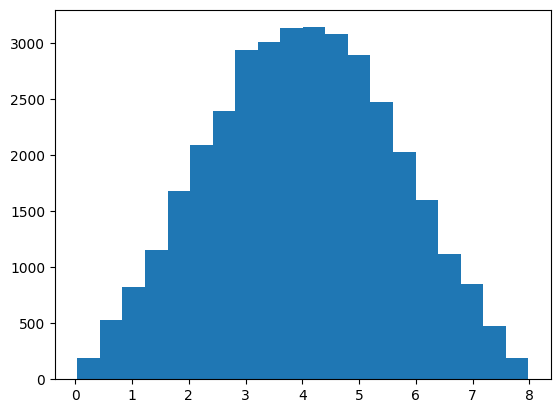

In [72]:
plt.hist(user_df['avg_delivery_days'], bins=20)

а теперь собери датасет относительно продукта и проанализируй какие продукты способствуют удержанию клиента

продукт сколько людей купили
общее количество(может быть более одного продукта в заказе)
если можно, то самые частые напарники
в какой категории(есть product_category, product_department)
цена продукта
собери информацию из customer review по ключевым словам типа red_list green_list counter

обучи модель, предскажи способствует ли продукт оттоку, проанализируй результаты, не забудь про статзначимость

In [85]:
# Ячейка 1. База: user churn (2+ дня) + подготовка транзакций product-level

import pandas as pd
import numpy as np
from itertools import combinations
from collections import Counter, defaultdict
from math import erf, sqrt

CHURN_DAYS = 30
CSV_PATH = "data.csv"

df = pd.read_csv(CSV_PATH)

# Базовые колонки
required = ["user_id", "order_id", "product_id", "created_at", "customer_review"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Нет нужных колонок: {missing}")

# Fallback-колонки
price_col = "sale_price" if "sale_price" in df.columns else ("retail_price" if "retail_price" in df.columns else None)
qty_col = "num_of_item" if "num_of_item" in df.columns else None
cat_col = "product_category" if "product_category" in df.columns else ("category" if "category" in df.columns else None)
dept_col = "product_department" if "product_department" in df.columns else ("department" if "department" in df.columns else None)
name_col = "product_name" if "product_name" in df.columns else ("name" if "name" in df.columns else None)

if price_col is None:
    raise ValueError("Не найдена цена (sale_price/retail_price)")
if cat_col is None or dept_col is None:
    raise ValueError("Не найдены category/department")

# Даты и числовые
df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
df = df.dropna(subset=["user_id", "order_id", "product_id", "created_at"]).copy()
df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
if qty_col is not None:
    df[qty_col] = pd.to_numeric(df[qty_col], errors="coerce").fillna(1)
else:
    df["num_of_item_tmp"] = 1
    qty_col = "num_of_item_tmp"

# User churn = не покупал 2+ дня от max даты в датасете
user_last = df.groupby("user_id", as_index=False)["created_at"].max().rename(columns={"created_at": "last_purchase_at"})
max_date = user_last["last_purchase_at"].max()
user_last["days_since_last"] = (max_date - user_last["last_purchase_at"]).dt.total_seconds() / 86400
user_last["churn"] = (user_last["days_since_last"] >= CHURN_DAYS).astype(int)

global_churn_rate = user_last["churn"].mean()
print("Users:", len(user_last), "| Global churn rate:", round(global_churn_rate, 4))

# Приклеиваем churn к событиям
df = df.merge(user_last[["user_id", "churn"]], on="user_id", how="left")


Users: 78064 | Global churn rate: 0.9149


In [86]:
# Ячейка 2. Product-level датасет: объем, напарники, категории, цена, review keywords, статзначимость

# --- 2.1 Базовые агрегаты по продукту ---
base_agg = df.groupby("product_id").agg(
    buyers_count=("user_id", "nunique"),
    total_quantity=(qty_col, "sum"),
    orders_count=("order_id", "nunique"),
    avg_price=(price_col, "mean"),
    median_price=(price_col, "median"),
).reset_index()

# user-product уникально (чтобы churn не дублировался строками товара)
user_product = df[["user_id", "product_id", "churn"]].drop_duplicates()
prod_churn = user_product.groupby("product_id").agg(
    buyers_for_churn=("user_id", "nunique"),
    churn_users=("churn", "sum"),
).reset_index()
prod_churn["product_churn_rate"] = prod_churn["churn_users"] / prod_churn["buyers_for_churn"]
prod_churn["churn_lift_vs_global"] = prod_churn["product_churn_rate"] - global_churn_rate

# --- 2.2 Категория/департамент/название ---
def mode_or_nan(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else np.nan

meta = df.groupby("product_id").agg(
    product_category=(cat_col, mode_or_nan),
    product_department=(dept_col, mode_or_nan),
).reset_index()

if name_col is not None:
    name_meta = df.groupby("product_id").agg(product_name=(name_col, mode_or_nan)).reset_index()
    meta = meta.merge(name_meta, on="product_id", how="left")
else:
    meta["product_name"] = meta["product_id"].astype(str)

# --- 2.3 Частые напарники (co-purchase в одном заказе) ---
order_prod = df[["order_id", "product_id"]].drop_duplicates()
pair_counter = Counter()

for _, g in order_prod.groupby("order_id")["product_id"]:
    products = sorted(set(g.tolist()))
    if len(products) > 1:
        for a, b in combinations(products, 2):
            pair_counter[(a, b)] += 1

partner_map = defaultdict(list)
for (a, b), cnt in pair_counter.items():
    partner_map[a].append((b, cnt))
    partner_map[b].append((a, cnt))

def top_partners(pid, k=3):
    arr = sorted(partner_map.get(pid, []), key=lambda x: x[1], reverse=True)[:k]
    ids = [x[0] for x in arr]
    cnts = [x[1] for x in arr]
    while len(ids) < k:
        ids.append(np.nan); cnts.append(np.nan)
    return ids + cnts

partners_df = pd.DataFrame(
    [(pid, *top_partners(pid, 3)) for pid in base_agg["product_id"]],
    columns=[
        "product_id",
        "partner_1_id", "partner_2_id", "partner_3_id",
        "partner_1_orders", "partner_2_orders", "partner_3_orders"
    ]
)

# Подставим имена партнеров (если есть)
id_to_name = meta.set_index("product_id")["product_name"].to_dict()
for i in [1, 2, 3]:
    partners_df[f"partner_{i}_name"] = partners_df[f"partner_{i}_id"].map(id_to_name)

# --- 2.4 Review keywords ---
red_list = ["bad", "poor", "late", "broken", "refund", "return", "expensive", "disappoint", "worse", "problem"]
green_list = ["good", "great", "excellent", "fast", "love", "perfect", "recommend", "happy", "quality", "satisfied"]
counter_list = ["but", "however", "although", "yet", "though"]

reviews = df[["product_id", "customer_review"]].copy()
reviews["customer_review"] = reviews["customer_review"].fillna("").astype(str).str.lower()

def kw_hits(text, kw_list):
    return sum(int(k in text) for k in kw_list)

reviews["green_hits"] = reviews["customer_review"].apply(lambda x: kw_hits(x, green_list))
reviews["red_hits"] = reviews["customer_review"].apply(lambda x: kw_hits(x, red_list))
reviews["counter_hits"] = reviews["customer_review"].apply(lambda x: kw_hits(x, counter_list))
reviews["review_nonempty"] = (reviews["customer_review"].str.len() > 0).astype(int)

review_agg = reviews.groupby("product_id").agg(
    review_count=("review_nonempty", "sum"),
    green_hits_sum=("green_hits", "sum"),
    red_hits_sum=("red_hits", "sum"),
    counter_hits_sum=("counter_hits", "sum"),
).reset_index()

review_agg["green_rate"] = review_agg["green_hits_sum"] / review_agg["review_count"].replace(0, np.nan)
review_agg["red_rate"] = review_agg["red_hits_sum"] / review_agg["review_count"].replace(0, np.nan)
review_agg["counter_rate"] = review_agg["counter_hits_sum"] / review_agg["review_count"].replace(0, np.nan)
review_agg["sentiment_proxy"] = review_agg["green_rate"].fillna(0) - review_agg["red_rate"].fillna(0)

# --- 2.5 Статзначимость churn lift (z-test пропорций vs global churn) ---
def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

sig = prod_churn.copy()
n = sig["buyers_for_churn"].astype(float)
p_hat = sig["product_churn_rate"].astype(float)
p0 = float(global_churn_rate)

se = np.sqrt((p0 * (1 - p0)) / n)
sig["z_stat"] = np.where(se > 0, (p_hat - p0) / se, np.nan)
sig["p_value"] = 2 * (1 - sig["z_stat"].abs().apply(norm_cdf))

# Benjamini-Hochberg (FDR)
tmp = sig[["product_id", "p_value"]].dropna().sort_values("p_value").reset_index(drop=True)
m = len(tmp)
tmp["rank"] = np.arange(1, m + 1)
tmp["p_adj_bh"] = (tmp["p_value"] * m / tmp["rank"]).clip(upper=1)
tmp["p_adj_bh"] = tmp["p_adj_bh"][::-1].cummin()[::-1]
sig = sig.merge(tmp[["product_id", "p_adj_bh"]], on="product_id", how="left")
sig["is_significant_5pct"] = (sig["p_adj_bh"] < 0.05).astype(int)

# Ярлык для ML: 1 = продукт способствует оттоку (churn_rate > global), 0 = не способствует
sig["target_product_churn"] = (sig["churn_lift_vs_global"] > 0).astype(int)

# --- 2.6 Финальный product-level датасет ---
product_df = (
    base_agg
    .merge(meta, on="product_id", how="left")
    .merge(prod_churn, on="product_id", how="left")
    .merge(sig[["product_id", "z_stat", "p_value", "p_adj_bh", "is_significant_5pct", "target_product_churn"]], on="product_id", how="left")
    .merge(review_agg, on="product_id", how="left")
    .merge(partners_df, on="product_id", how="left")
)

# Чистка
num_fill0 = [
    "avg_price", "median_price", "review_count", "green_hits_sum", "red_hits_sum", "counter_hits_sum",
    "green_rate", "red_rate", "counter_rate", "sentiment_proxy",
    "partner_1_orders", "partner_2_orders", "partner_3_orders"
]
for c in num_fill0:
    if c in product_df.columns:
        product_df[c] = pd.to_numeric(product_df[c], errors="coerce").fillna(0)

product_df["product_category"] = product_df["product_category"].fillna("unknown")
product_df["product_department"] = product_df["product_department"].fillna("unknown")
product_df["target_product_churn"] = product_df["target_product_churn"].fillna(0).astype(int)

print("Product dataset shape:", product_df.shape)
product_df.head(3)


Product dataset shape: (29025, 35)


,product_id,buyers_count,total_quantity,orders_count,avg_price,median_price,product_category,product_department,product_name,buyers_for_churn,...,sentiment_proxy,partner_1_id,partner_2_id,partner_3_id,partner_1_orders,partner_2_orders,partner_3_orders,partner_1_name,partner_2_name,partner_3_name
0,1,7,48,7,49.0,49.0,Tops & Tees,Women,Seven7 Women's Long Sleeve Stripe Belted Top,7,...,0.857143,11987.0,1276.0,7583.0,1.0,1.0,1.0,Gracya Mon Amour Black and Red Suspender Belt ...,Woolrich Women's Sweetfern Cardigan,Ropa Voga Womens Solid Long Sleeves Blazer Jac...
1,2,5,33,5,69.5,69.5,Tops & Tees,Women,Calvin Klein Women's MSY Crew Neck Roll Sleeve,5,...,1.200000,1381.0,4383.0,6197.0,1.0,1.0,1.0,Coupe Collection Women's Abel Cardigan,Lucky Brand Women's Sofia Boot Jean,Teez-Her Skinny Snake Print Legging
2,3,6,48,6,69.5,69.5,Tops & Tees,Women,Calvin Klein Jeans Women's Solid Flyaway Shirt,6,...,1.166667,146.0,6647.0,13601.0,1.0,1.0,1.0,Allegra K Woman Beige Black Scoop Neck Dotted ...,Mango Women's Jacquard Shorts - Jacquard,Lauren Solid Color Stunning Pashmina Scarf/Wrap


In [87]:
# Ячейка 3. ML-модель: предсказываем, способствует ли продукт оттоку

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

features = [
    "buyers_count", "total_quantity", "orders_count",
    "avg_price", "median_price",
    "review_count", "green_rate", "red_rate", "counter_rate", "sentiment_proxy",
    "partner_1_orders", "partner_2_orders", "partner_3_orders",
    "product_category", "product_department"
]
target = "target_product_churn"

data = product_df[features + [target]].copy()
X = data[features]
y = data[target]

cat_cols = ["product_category", "product_department"]
num_cols = [c for c in features if c not in cat_cols]

prep = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

model = Pipeline([
    ("prep", prep),
    ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
pred = model.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print("\nClassification report:\n", classification_report(y_test, pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))


ROC-AUC: 0.6378

Classification report:
               precision    recall  f1-score   support

           0     0.5661    0.5825    0.5742      3346
           1     0.6337    0.6180    0.6258      3911

    accuracy                         0.6016      7257
   macro avg     0.5999    0.6002    0.6000      7257
weighted avg     0.6025    0.6016    0.6020      7257

Confusion matrix:
 [[1949 1397]
 [1494 2417]]


/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ 

In [88]:
# Ячейка 4. Что удерживает/что толкает к оттоку + статзначимость

import numpy as np

# Влияние признаков (логрег)
prep = model.named_steps["prep"]
clf = model.named_steps["clf"]
feat_names = prep.get_feature_names_out()
coef = clf.coef_[0]

coef_df = pd.DataFrame({
    "feature": feat_names,
    "coef": coef,
    "odds_ratio": np.exp(coef),
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("Топ признаков модели:")
display(coef_df.head(20)[["feature", "coef", "odds_ratio"]])

# Прогноз по каждому продукту
product_pred = product_df.copy()
product_pred["pred_churn_prob"] = model.predict_proba(product_pred[features])[:, 1]
product_pred["pred_churn_label"] = (product_pred["pred_churn_prob"] >= 0.5).astype(int)

# Продукты, которые статистически удерживают клиентов
retention_sig = product_pred[
    (product_pred["churn_lift_vs_global"] < 0) &
    (product_pred["is_significant_5pct"] == 1)
].sort_values("churn_lift_vs_global")

# Продукты, которые статистически ассоциированы с оттоком
churn_sig = product_pred[
    (product_pred["churn_lift_vs_global"] > 0) &
    (product_pred["is_significant_5pct"] == 1)
].sort_values("churn_lift_vs_global", ascending=False)

print("\nТОП-10 продуктов, способствующих удержанию (значимо):")
display(retention_sig[[
    "product_id", "product_name", "product_category", "product_department",
    "buyers_count", "product_churn_rate", "churn_lift_vs_global", "p_adj_bh",
    "green_rate", "red_rate", "avg_price",
    "partner_1_name", "partner_1_orders"
]].head(10))

print("\nТОП-10 продуктов, способствующих оттоку (значимо):")
display(churn_sig[[
    "product_id", "product_name", "product_category", "product_department",
    "buyers_count", "product_churn_rate", "churn_lift_vs_global", "p_adj_bh",
    "green_rate", "red_rate", "avg_price",
    "partner_1_name", "partner_1_orders"
]].head(10))

print("\nКраткие выводы для защиты:")
print("1) Смотри на churn_lift_vs_global: < 0 — продукт удерживает, > 0 — связан с оттоком.")
print("2) Учитывай только значимые продукты (p_adj_bh < 0.05).")
print("3) По модели: признаки с положительным coef повышают шанс, что продукт 'отточный'; с отрицательным — что удерживающий.")
print("4) По reviews: высокий red_rate обычно связан с оттоком, высокий green_rate — с удержанием (проверь top-листы выше).")


Топ признаков модели:


,feature,coef,odds_ratio
15,cat__product_category_Blazers & Jackets,0.184502,1.202620
5,num__review_count,-0.179342,0.835820
2,num__orders_count,-0.174998,0.839459
32,cat__product_category_Socks & Hosiery,-0.169692,0.843925
0,num__buyers_count,-0.167239,0.845997
38,cat__product_category_Underwear,0.092517,1.096932
25,cat__product_category_Pants,-0.092109,0.912005
37,cat__product_category_Tops & Tees,0.088361,1.092382
31,cat__product_category_Socks,0.080496,1.083825
36,cat__product_category_Swim,-0.080446,0.922705



ТОП-10 продуктов, способствующих удержанию (значимо):


/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,product_id,product_name,product_category,product_department,buyers_count,product_churn_rate,churn_lift_vs_global,p_adj_bh,green_rate,red_rate,avg_price,partner_1_name,partner_1_orders
5646,5676,WHAT GOES AROUND COMES AROUND Women's Colette ...,Pants & Capris,Women,2,0.0,-0.914929,0.001959,0.5,0.5,24.170000,Democracy Women's Triple Collar Woven Surplus ...,1.0
10731,10788,Hanky Panky Signature Lace Low Rise Thong 5-Pa...,Intimates,Women,2,0.0,-0.914929,0.001959,1.0,0.0,90.000000,NaN,0.0
10479,10536,Goddess Women's Alice Underwire Full Cup Bra,Intimates,Women,2,0.0,-0.914929,0.001959,1.0,0.0,46.000000,Burton Women's Her Logo Zip Hoodie,1.0
9504,9558,Calvin Klein Women's Mix Essentials Short Robe...,Sleep & Lounge,Women,2,0.0,-0.914929,0.001959,1.5,0.0,75.000000,NaN,0.0
8580,8627,JOU JOU Classic Herringbone Coat W/ Pockets [1...,Outerwear & Coats,Women,2,0.0,-0.914929,0.001959,1.5,0.0,39.990002,NaN,0.0
8467,8514,Kristen Blake Women's Fly Front Hooded Ruffle,Outerwear & Coats,Women,2,0.0,-0.914929,0.001959,2.0,0.0,129.309998,United Face Womens Lambskin Leather Bomber Jacket,1.0
8127,8170,EVAN PICONE Women's 3-Button Striped Jacket/Pa...,Suits,Women,2,0.0,-0.914929,0.001959,1.0,0.0,124.000000,Cuddl Duds Women's V-neck Tank Sweater,1.0
13294,13362,Hurley Juniors Line Drive Tunnel Pant,Swim,Women,2,0.0,-0.914929,0.001959,1.5,0.0,37.000000,Trixxi Juniors Blousant Knit Dress,1.0
14322,14393,Momo Maternity Women's 'Athena' Grecian Tunic ...,Maternity,Women,2,0.0,-0.914929,0.001959,1.5,0.0,78.000000,Hanro Women's Delicate Tank Top,1.0
5918,5950,Anna-Kaci S/M Fit Pink Blue and Yellow Multico...,Leggings,Women,2,0.0,-0.914929,0.001959,1.5,0.0,15.900000,Bettty Boop Black Kiss Pajamas for Juniors,1.0



ТОП-10 продуктов, способствующих оттоку (значимо):


,product_id,product_name,product_category,product_department,buyers_count,product_churn_rate,churn_lift_vs_global,p_adj_bh,green_rate,red_rate,avg_price,partner_1_name,partner_1_orders



Краткие выводы для защиты:
1) Смотри на churn_lift_vs_global: < 0 — продукт удерживает, > 0 — связан с оттоком.
2) Учитывай только значимые продукты (p_adj_bh < 0.05).
3) По модели: признаки с положительным coef повышают шанс, что продукт 'отточный'; с отрицательным — что удерживающий.
4) По reviews: высокий red_rate обычно связан с оттоком, высокий green_rate — с удержанием (проверь top-листы выше).
